Phase 5: Machine Learning Model Training and Evaluation

Step 1: Train Logistic Regression Model

In [1]:
import pandas as pd
import joblib

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
X_train = pd.read_csv(
    "../data/processed/X_train_smote.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train_smote.csv"
).squeeze()

X_test = pd.read_csv(
    "../data/processed/X_test_scaled.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [3]:
print("Training Features :", X_train.shape)

print("Training Labels :", y_train.shape)

print("Testing Features :", X_test.shape)

print("Testing Labels :", y_test.shape)

Training Features : (453204, 30)
Training Labels : (453204,)
Testing Features : (56746, 30)
Testing Labels : (56746,)


In [4]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [5]:
lr_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [6]:
y_pred = lr_model.predict(
    X_test
)

In [8]:
y_prob = lr_model.predict_proba(
    X_test
)[:,1]

In [9]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

In [10]:
precision = precision_score(
    y_test,
    y_pred
)

In [11]:
recall = recall_score(
    y_test,
    y_pred
)

In [12]:
f1 = f1_score(
    y_test,
    y_pred
)

In [13]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [14]:
print(f"Accuracy : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC AUC : {roc_auc:.4f}")

Accuracy : 0.9737
Precision : 0.0530
Recall : 0.8737
F1 Score : 0.1000
ROC AUC : 0.9619


In [15]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[55169  1482]
 [   12    83]]


In [16]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [17]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results.to_csv(
    "../reports/logistic_regression_results.csv",
    index=False
)

In [24]:
results.to_pickle(
    "../models/logistic_regression_results.pk1",
)

Step 2: Train Decision Tree Classifier

In [7]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [8]:
X_train = pd.read_csv(
    "../data/processed/X_train_smote.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train_smote.csv"
).squeeze()

X_test = pd.read_csv(
    "../data/processed/X_test_scaled.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [9]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(453204, 30)
(453204,)
(56746, 30)
(56746,)


In [10]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

In [11]:
criterion="gini"

In [12]:
max_depth=10

In [13]:
min_samples_split=20

In [14]:
min_samples_leaf=10

In [15]:
random_state=42

In [16]:
dt_model.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [17]:
y_pred = dt_model.predict(
    X_test
)

In [18]:
y_prob = dt_model.predict_proba(
    X_test
)[:,1]

In [19]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [20]:
print(f"Accuracy : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC-AUC : {roc_auc:.4f}")

Accuracy : 0.9865
Precision : 0.0905
Recall : 0.7789
F1 Score : 0.1621
ROC-AUC : 0.8732


In [21]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[55907   744]
 [   21    74]]


In [22]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.09      0.78      0.16        95

    accuracy                           0.99     56746
   macro avg       0.55      0.88      0.58     56746
weighted avg       1.00      0.99      0.99     56746



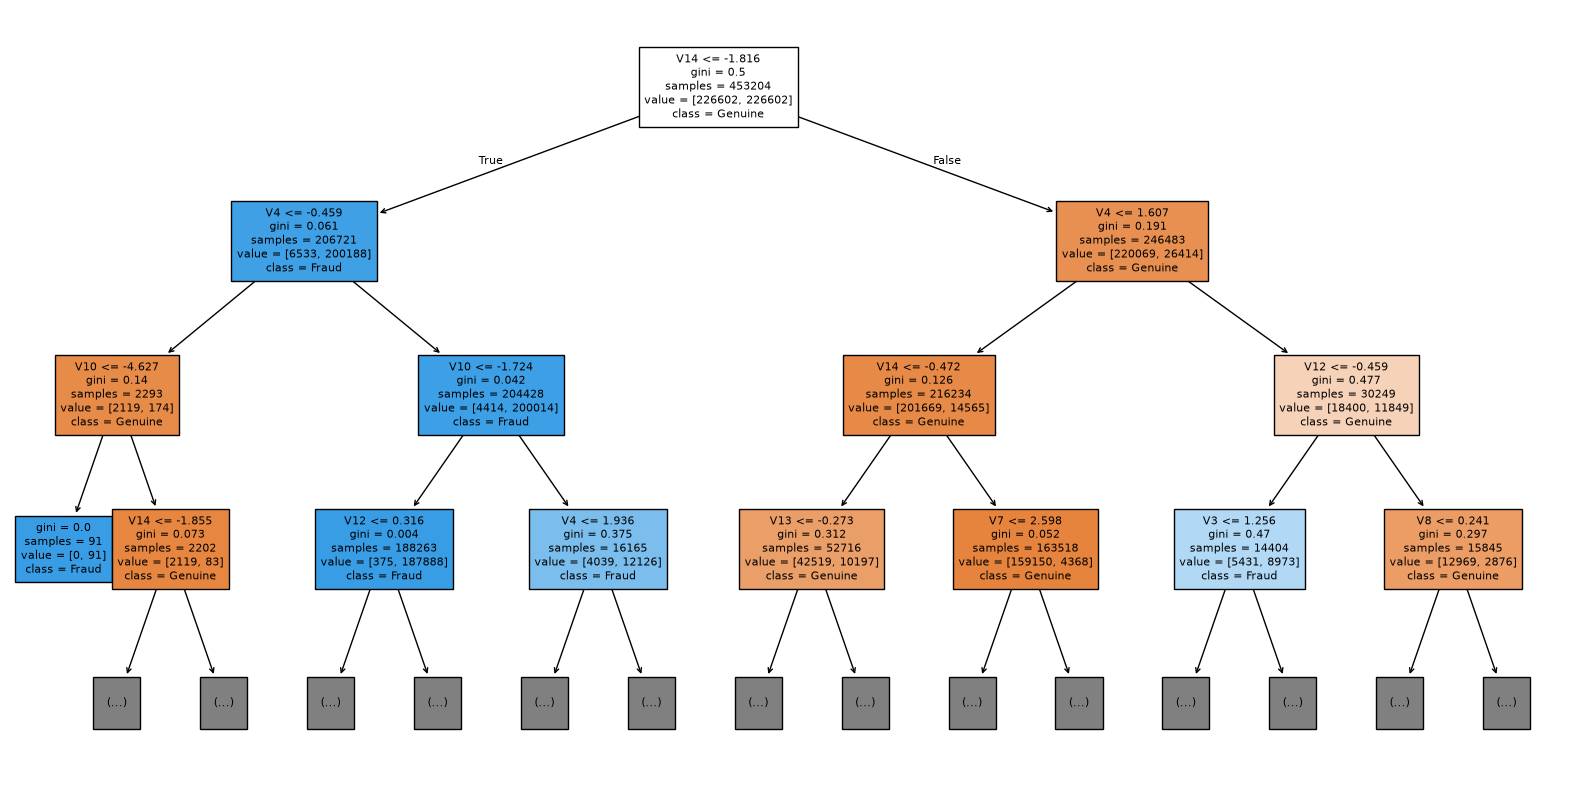

In [23]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=["Genuine","Fraud"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.savefig(
    "../images/decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

   Feature  Importance
14     V14    0.778695
4       V4    0.060493
12     V12    0.018680
3       V3    0.015645
13     V13    0.015371
9       V9    0.014056
10     V10    0.012205
29  Amount    0.009145
8       V8    0.007765
21     V21    0.007322


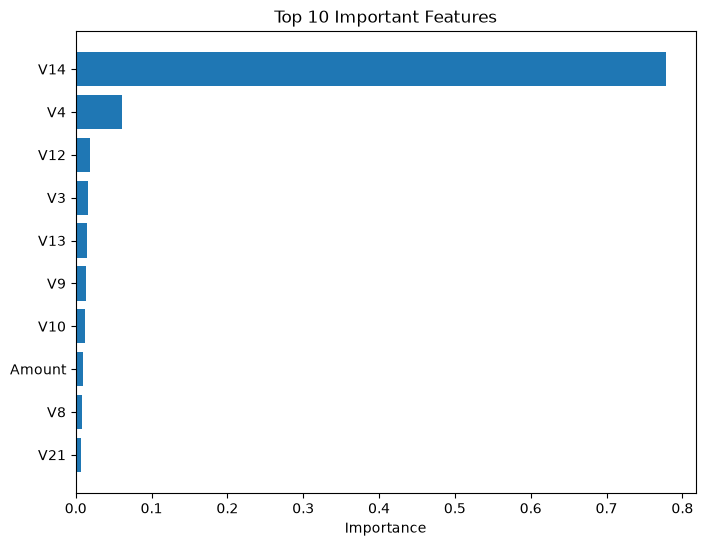

In [25]:
top_features = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.savefig(
    "../images/decision_tree_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
joblib.dump(
    dt_model,
    "../models/decision_tree.pkl"
)

['../models/decision_tree.pkl']

In [28]:


results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results.to_csv(
    "../reports/decision_tree_results.csv",
    index=False
)

Step 3: Train Random Forest Classifier

In [29]:


import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [30]:
X_train = pd.read_csv(
    "../data/processed/X_train_smote.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train_smote.csv"
).squeeze()

X_test = pd.read_csv(
    "../data/processed/X_test_scaled.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [31]:
X_train = pd.read_csv(
    "../data/processed/X_train_smote.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train_smote.csv"
).squeeze()

X_test = pd.read_csv(
    "../data/processed/X_test_scaled.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [32]:
rf_model = RandomForestClassifier(

    n_estimators=200,

    criterion="gini",

    max_depth=15,

    min_samples_split=10,

    min_samples_leaf=5,

    random_state=42,

    n_jobs=-1
)

In [33]:
rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [34]:
y_pred = rf_model.predict(
    X_test
)

In [35]:
y_prob = rf_model.predict_proba(
    X_test
)[:,1]

In [36]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [37]:
print(f"Accuracy : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC-AUC : {roc_auc:.4f}")

Accuracy : 0.9992
Precision : 0.7629
Recall : 0.7789
F1 Score : 0.7708
ROC-AUC : 0.9765


In [38]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.76      0.78      0.77        95

    accuracy                           1.00     56746
   macro avg       0.88      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746



In [39]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.76      0.78      0.77        95

    accuracy                           1.00     56746
   macro avg       0.88      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746



In [40]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(
    importance.head(10)
)

   Feature  Importance
14     V14    0.190887
10     V10    0.116851
12     V12    0.103534
4       V4    0.102680
17     V17    0.093272
16     V16    0.058899
3       V3    0.057703
11     V11    0.056259
2       V2    0.032052
7       V7    0.021413


In [41]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(
    importance.head(10)
)

   Feature  Importance
14     V14    0.190887
10     V10    0.116851
12     V12    0.103534
4       V4    0.102680
17     V17    0.093272
16     V16    0.058899
3       V3    0.057703
11     V11    0.056259
2       V2    0.032052
7       V7    0.021413


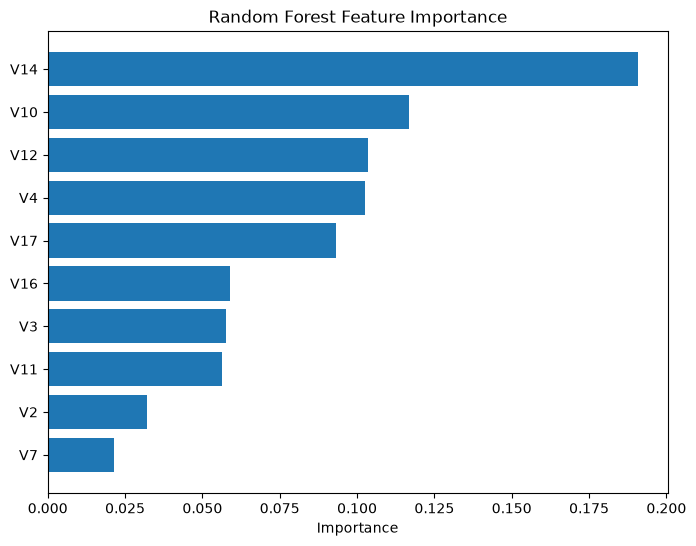

In [42]:
top10 = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.savefig(
    "../images/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

})

results.to_csv(
    "../reports/random_forest_results.csv",
    index=False
)

In [44]:
joblib.dump(
    rf_model,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']

Step 4: Train XGBoost Classifier

In [45]:
import xgboost
print(xgboost.__version__)

3.3.0


In [46]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [47]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [48]:
X_train = pd.read_csv(
    "../data/processed/X_train_smote.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train_smote.csv"
).squeeze()

X_test = pd.read_csv(
    "../data/processed/X_test_scaled.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [49]:
xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    min_child_weight=3,

    subsample=0.8,

    colsample_bytree=0.8,

    gamma=0,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42
)

In [50]:
xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [51]:
y_pred = xgb_model.predict(X_test)

In [52]:
y_prob = xgb_model.predict_proba(X_test)[:,1]

In [53]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [54]:

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")

Accuracy : 0.9985
Precision : 0.5423
Recall : 0.8105
F1 Score : 0.6498
ROC-AUC : 0.9756


In [55]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[56586    65]
 [   18    77]]


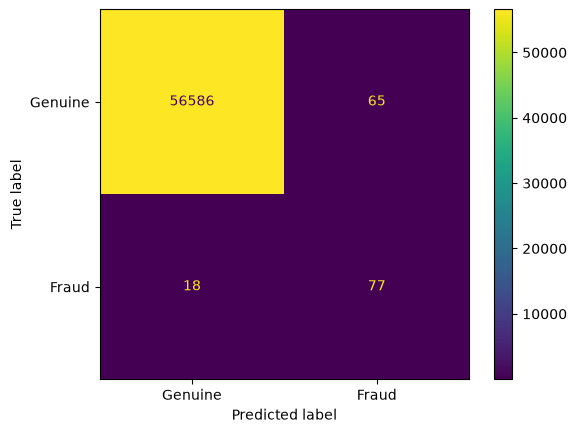

In [56]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine","Fraud"]
)

disp.plot()

plt.savefig(
    "../images/xgboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.54      0.81      0.65        95

    accuracy                           1.00     56746
   macro avg       0.77      0.90      0.82     56746
weighted avg       1.00      1.00      1.00     56746



In [59]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.54      0.81      0.65        95

    accuracy                           1.00     56746
   macro avg       0.77      0.90      0.82     56746
weighted avg       1.00      1.00      1.00     56746



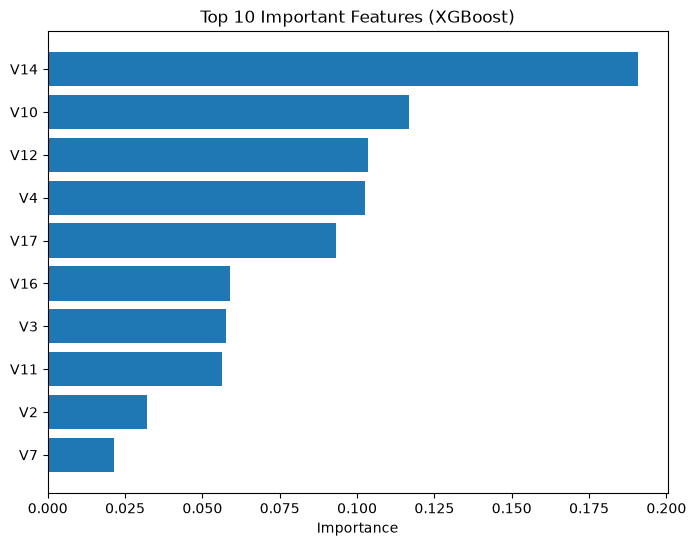

In [60]:
top10 = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Important Features (XGBoost)")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.savefig(
    "../images/xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [61]:
joblib.dump(
    xgb_model,
    "../models/xgboost.pkl"
)

['../models/xgboost.pkl']

In [62]:
results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

})

results.to_csv(
    "../reports/xgboost_results.csv",
    index=False
)

Step 5: Train LightGBM Classifier

In [63]:
import lightgbm

print(lightgbm.__version__)

4.7.0


In [64]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [66]:
X_train = pd.read_csv(
    "../data/processed/X_train_smote.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train_smote.csv"
).squeeze()

X_test = pd.read_csv(
    "../data/processed/X_test_scaled.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [68]:
print("Training Shape :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Shape :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Shape : (453204, 30)
Training Labels : (453204,)
Testing Shape : (56746, 30)
Testing Labels : (56746,)


In [69]:
lgbm_model = LGBMClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=8,

    num_leaves=31,

    min_child_samples=20,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    verbose=-1
)

In [72]:
print(lgbm_model)


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=8,
               n_estimators=300, random_state=42, subsample=0.8, verbose=-1)


In [74]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1
)

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 226602, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039454 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 453204, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [76]:
y_pred = lgbm_model.predict(X_test)

In [77]:
y_prob = lgbm_model.predict_proba(X_test)[:,1]

In [78]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [79]:
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")

Accuracy : 0.9986
Precision : 0.5486
Recall : 0.8316
F1 Score : 0.6611
ROC-AUC : 0.9635


In [80]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[56586    65]
 [   16    79]]


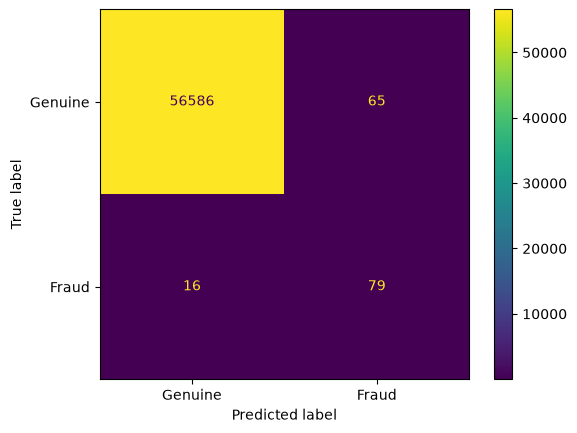

In [81]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine","Fraud"]
)

disp.plot()

plt.savefig(
    "../images/lightgbm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.55      0.83      0.66        95

    accuracy                           1.00     56746
   macro avg       0.77      0.92      0.83     56746
weighted avg       1.00      1.00      1.00     56746



In [83]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": lgbm_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(
    importance.head(10)
)

   Feature  Importance
4       V4         213
14     V14         211
12     V12         141
8       V8         136
3       V3         136
18     V18         131
1       V1         125
11     V11         120
26     V26         118
17     V17         115


In [84]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": lgbm_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(
    importance.head(10)
)

   Feature  Importance
4       V4         213
14     V14         211
12     V12         141
8       V8         136
3       V3         136
18     V18         131
1       V1         125
11     V11         120
26     V26         118
17     V17         115


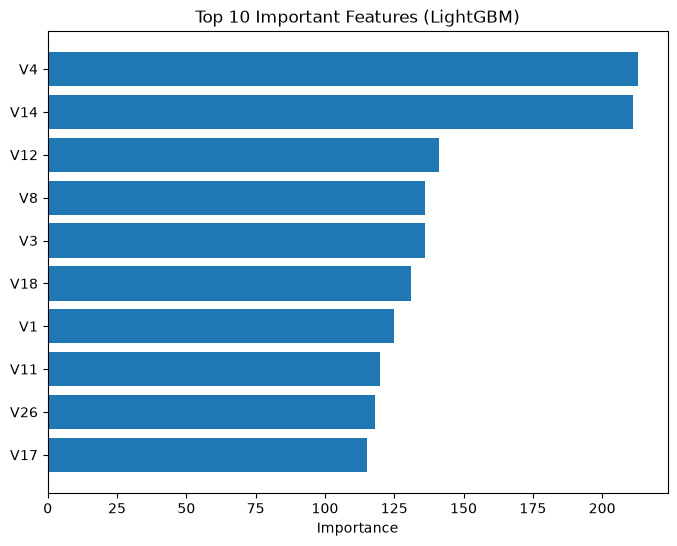

In [85]:
top10 = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Important Features (LightGBM)")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.savefig(
    "../images/lightgbm_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [86]:
results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

})

results.to_csv(
    "../reports/lightgbm_results.csv",
    index=False
)

In [87]:
joblib.dump(
    lgbm_model,
    "../models/lightgbm.pkl"
)

['../models/lightgbm.pkl']